In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [3]:
DATA_FILE      = "clean_pipeline_data.csv"
ELEMENTAL_COLS = ["Fe","Ni","Co","Cr","Mn","C","Mo","Si","Cu","Al","W","V","Ti","Nb"]
TARGET         = "Tensile Strength: Ultimate (UTS) (psi)"

In [4]:
df = pd.read_csv(DATA_FILE)
df = df[df["compositional_sum_flag"] == "PASS"]
X  = df[ELEMENTAL_COLS]
y  = df[TARGET]
print(f"Loaded {len(df)} valid rows.")

Loaded 2664 valid rows.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} and Test: {len(X_test)}")

Train: 2131 and Test: 533


In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Linear Regression trained.")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Linear Regression trained.
Random Forest trained.


In [7]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_rf  = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"\nLinear Regression - R(squared): {r2_lr:.4f} and MAE: {mae_lr:.1f} psi")
print(f"Random Forest     - R(squared): {r2_rf:.4f} and MAE: {mae_rf:.1f} psi")


Linear Regression - R(squared): 0.0637 and MAE: 125.6 psi
Random Forest     - R(squared): 0.7403 and MAE: 60.2 psi



actual_vs_predicted.png


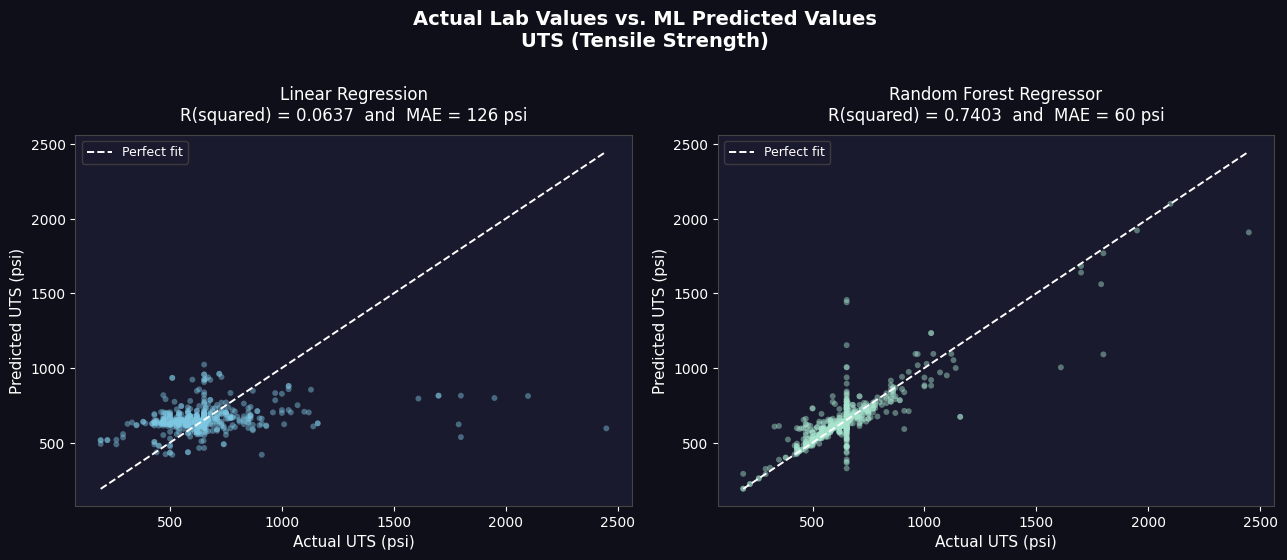

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor("#0f0f1a")

for ax, y_pred, r2, mae, model_name, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    [r2_lr, r2_rf],
    [mae_lr, mae_rf],
    ["Linear Regression", "Random Forest Regressor"],
    ["#7ec8e3", "#a8e6cf"]
):
    ax.set_facecolor("#1a1a2e")
    ax.scatter(y_test, y_pred, alpha=0.45, s=18, color=color, edgecolors="none")
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "w--", linewidth=1.4, label="Perfect fit")
    ax.set_xlabel("Actual UTS (psi)", color="white", fontsize=11)
    ax.set_ylabel("Predicted UTS (psi)", color="white", fontsize=11)
    ax.set_title(f"{model_name}\nR(squared) = {r2:.4f}  and  MAE = {mae:.0f} psi",
                 color="white", fontsize=12, pad=10)
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#444")
    ax.legend(facecolor="#1a1a2e", edgecolor="#444", labelcolor="white", fontsize=9)

plt.suptitle("Actual Lab Values vs. ML Predicted Values\nUTS (Tensile Strength)",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight", facecolor="#0f0f1a")
print("\nactual_vs_predicted.png")
plt.show()

In [9]:
joblib.dump(rf, "random_forest_model.pkl")
print("\nsaved as random_forest_model.pkl")



saved as random_forest_model.pkl


In [10]:
try:
    from google.colab import files
    files.download("random_forest_model.pkl")
    files.download("actual_vs_predicted.png")
    print("Downloads triggered.")
except ImportError:
    print("Not in Colab:  find the files in your working directory.")

Not in Colab:  find the files in your working directory.
